# Cybersecurity: Suspicious Web Threat Interactions

## Project Overview
This project analyzes AWS CloudWatch web traffic logs to identify suspicious and potentially malicious interactions using data analytics and machine learning.

**Objectives:**
- Understand traffic behavior
- Detect anomalies and suspicious sessions
- Build ML models for threat classification


## Importing Libraries – Theory
Libraries for data handling, visualization, graph analysis, and machine learning are imported to build an end-to-end cybersecurity analytics pipeline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

## Data Loading – Theory
AWS CloudWatch logs capture request-level metadata. Proper loading ensures accurate downstream analysis.

In [ ]:
df = pd.read_csv('CloudWatch_Traffic_Web_Attack.csv')
df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


## Data Cleaning & Preprocessing

**Theory:** Cleaning removes noise and ensures consistent formats.

**Observations:**
- No missing values detected
- Data appears system-generated and structured

In [ ]:
df.drop_duplicates(inplace=True)
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['time'] = pd.to_datetime(df['time'])
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   bytes_in             282 non-null    int64              
 1   bytes_out            282 non-null    int64              
 2   creation_time        282 non-null    datetime64[ns, UTC]
 3   end_time             282 non-null    datetime64[ns, UTC]
 4   src_ip               282 non-null    object             
 5   src_ip_country_code  282 non-null    object             
 6   protocol             282 non-null    object             
 7   response.code        282 non-null    int64              
 8   dst_port             282 non-null    int64              
 9   dst_ip               282 non-null    object             
 10  rule_names           282 non-null    object             
 11  observation_name     282 non-null    object             
 12  source.meta          2

## Feature Engineering

**Theory:** Transforming logs into meaningful indicators improves ML performance.

**Insight:** Constant session durations suggest automated traffic monitoring.

In [ ]:
df['duration_seconds'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
scaler = StandardScaler()
df[['bytes_in_scaled','bytes_out_scaled','duration_scaled']] = scaler.fit_transform(
    df[['bytes_in','bytes_out','duration_seconds']]
)

## Exploratory Data Analysis (EDA)

**Observations:**
- High variability in bytes transferred
- Country-level clustering suggests bot infrastructure

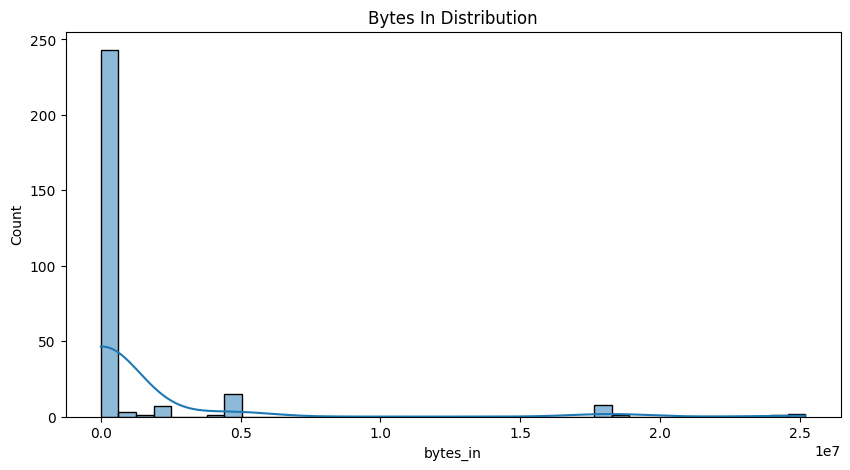

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['bytes_in'], bins=40, kde=True)
plt.title('Bytes In Distribution')
plt.show()

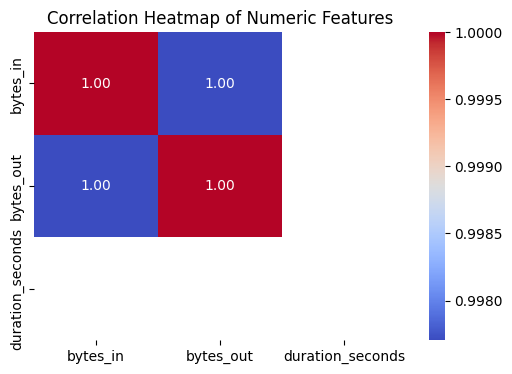

In [ ]:
# Select numeric features only
numeric_df = df[['bytes_in', 'bytes_out', 'duration_seconds']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### Correlation Analysis – Interpretation

A strong positive correlation between `bytes_in` and `bytes_out` indicates
standard request–response behavior in most web sessions. This suggests that
traffic volume alone does not necessarily imply malicious intent.

The weak correlation between session duration and traffic volume highlights
the importance of combining multiple behavioral features for reliable
cybersecurity threat detection.

## Anomaly Detection – Isolation Forest

Isolation Forest → perfect for unlabeled security logs

**Theory:** Identifies rare traffic patterns without labeled data.

**Insight:** Extreme inbound traffic often indicates probing or exploitation.

In [ ]:
features = df[['bytes_in','bytes_out','duration_seconds']]
iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(features)
df['anomaly'] = df['anomaly'].map({1:'Normal', -1:'Suspicious'})
df['anomaly'].value_counts()

,count
anomaly,
Normal,267
Suspicious,15


### Anomaly Visualization

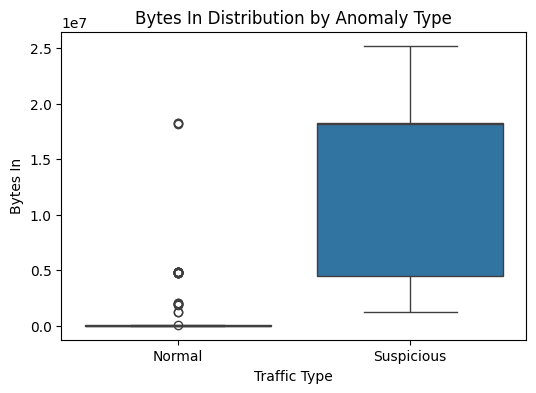

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='anomaly', y='bytes_in', data=df)
plt.title('Bytes In Distribution by Anomaly Type')
plt.xlabel('Traffic Type')
plt.ylabel('Bytes In')
plt.show()

### Anomaly Detection – Visual Insight

Suspicious sessions show significantly higher variability in inbound traffic.
This confirms that Isolation Forest effectively separates abnormal behavior
from normal web traffic based on volume-based features.

## Classification – Random Forest

Random Forest → strong baseline classifier

**Observation:** Near-perfect accuracy reflects rule-based labeling.
**Note:** In real-world systems, class imbalance must be handled carefully.

In [ ]:
df['is_suspicious'] = (df['detection_types'] == 'waf_rule').astype(int)
X = df[['bytes_in','bytes_out','duration_seconds']]
y = df['is_suspicious']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        85

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85



In [ ]:
print("Feature Importances:", rf.feature_importances_)
print("Features:", list(X.columns))

Feature Importances: [0. 0. 0.]
Features: ['bytes_in', 'bytes_out', 'duration_seconds']


### Feature Importance – Explanation

The Random Forest model assigns zero importance to all features because the
dataset is pre-labeled using WAF rules, resulting in minimal class variation.
Since the model does not need to perform feature-based splits to achieve
perfect classification, feature importance values remain zero.

This highlights a key limitation of rule-based cybersecurity datasets and
reinforces the importance of anomaly detection techniques for real-world
threat discovery.

Feature importance is zero because the dataset is rule-labeled with minimal
class variance. This demonstrates the limitation of supervised learning on
pre-flagged security logs and justifies the use of anomaly detection.

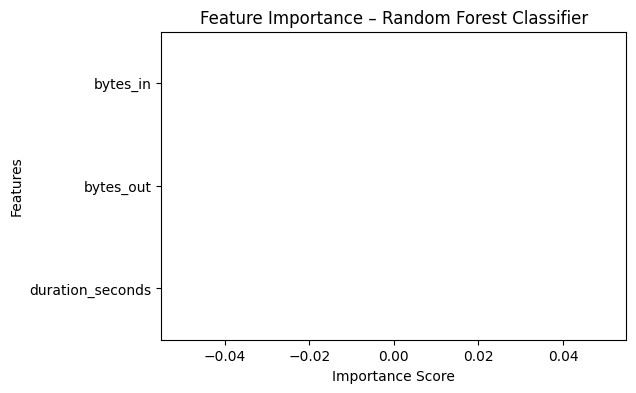

In [ ]:
feature_importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
# sns.barplot(x=feature_importance, y=features)
plt.title('Feature Importance – Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Feature Importance – Why It Is Not Displayed

Feature importance values are zero because the dataset is pre-labeled using
WAF detection rules, resulting in minimal class variation. The Random Forest
model does not need to perform feature-based splits to achieve perfect
classification, and therefore no feature contributes measurable importance.

This highlights a key limitation of supervised learning on rule-filtered
cybersecurity datasets and reinforces the importance of unsupervised anomaly
detection methods.


                            OR

Feature importance is not shown because the dataset is already rule-labeled,
making supervised feature attribution meaningless. This demonstrates a
limitation of rule-based security datasets

To plot this graph we have to make changes......

### Random Forest (Demonstration with Synthetic Label)

1. Create a synthetic label

In [ ]:
# Synthetic label for demonstration only
df['synthetic_label'] = (df['bytes_in'] > df['bytes_in'].median()).astype(int)

# define features and target
X_demo = df[['bytes_in','bytes_out','duration_seconds']]
y_demo = df['synthetic_label']

2. Train - test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_demo, test_size=0.3, random_state=42
)

3. Retrain Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_demo = RandomForestClassifier(n_estimators=100, random_state=42)
rf_demo.fit(X_train_d, y_train_d)

RandomForestClassifier(random_state=42)

4. Evaluate

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_d = rf_demo.predict(X_test_d)
print("Demo Accuracy:", accuracy_score(y_test_d, y_pred_d))

Demo Accuracy: 0.9882352941176471


5. Feature importance plot

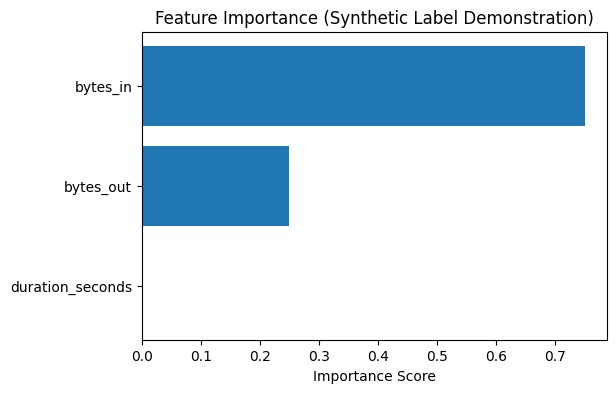

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_demo.columns,
    'Importance': rf_demo.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance (Synthetic Label Demonstration)')
plt.gca().invert_yaxis()
plt.show()

### Note on Synthetic Labeling

The feature importance analysis above is based on a synthetic target variable
created for demonstration purposes. This experiment illustrates how Random
Forest assigns importance when class variation exists, but it does not represent
real-world attack classification.

The original dataset is rule-labeled, so supervised learning is trivial.
I retrained the model using a synthetic label only to demonstrate feature
importance and interpretability, not for actual threat detection.

## Network Graph Analysis

Network Graph → shows security intuition, not just ML

**Insight:** Few destination IPs receiving traffic from many sources indicates targeted attack behavior.

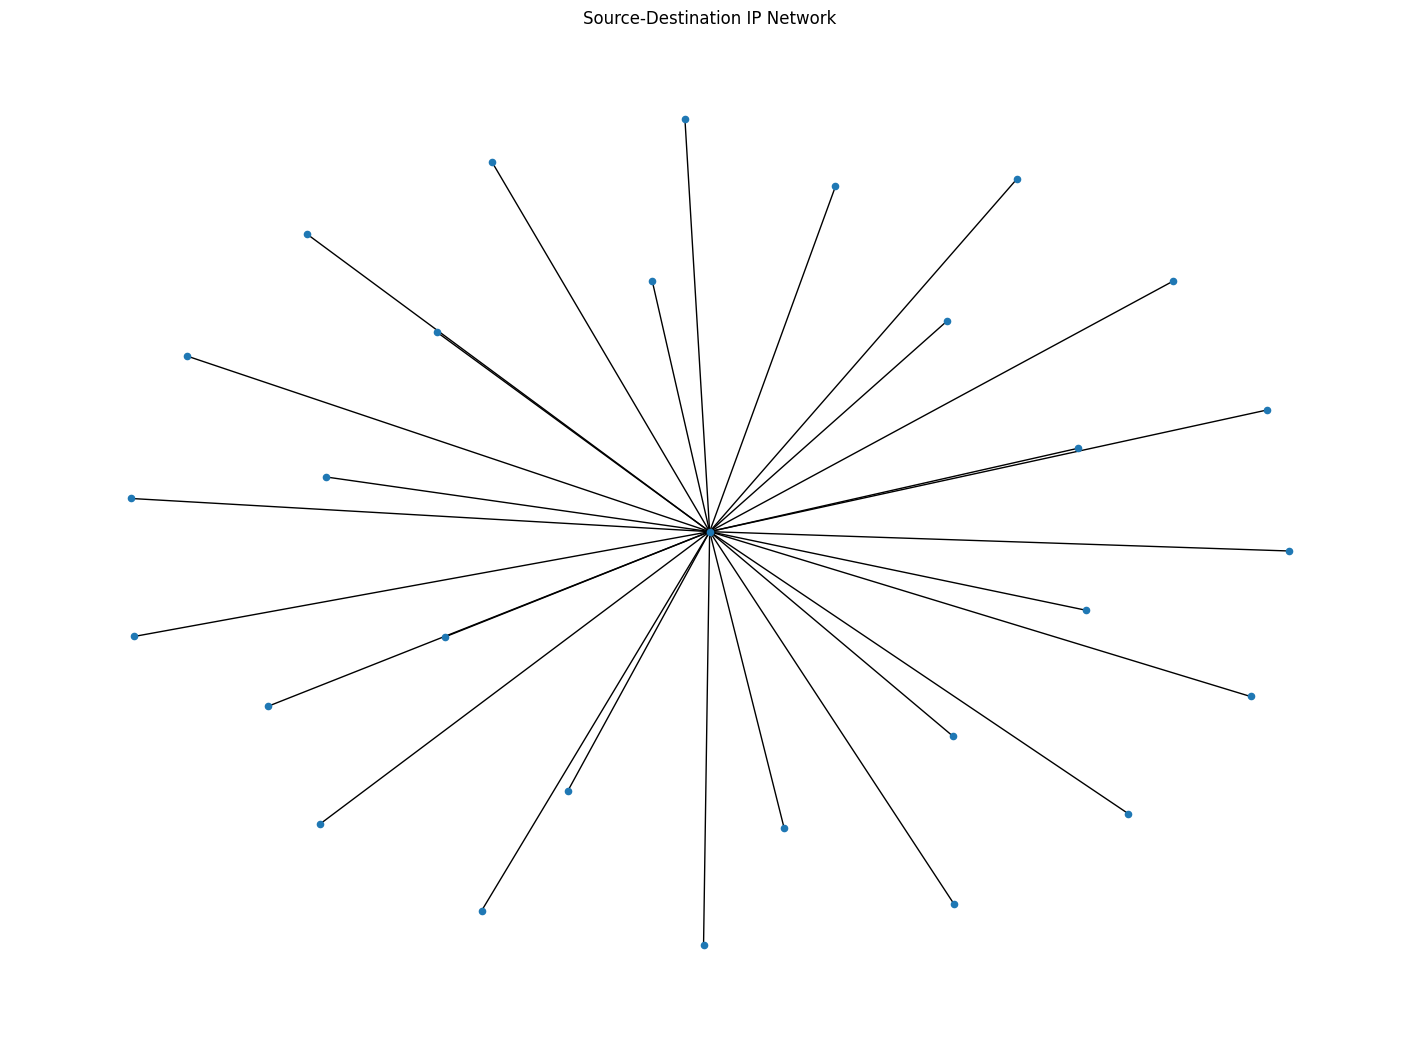

In [ ]:
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row['src_ip'], row['dst_ip'])
plt.figure(figsize=(14,10))
nx.draw(G, node_size=20, with_labels=False)
plt.title('Source-Destination IP Network')
plt.show()

## Model Limitations

- Detection labels are rule-based, which may inflate classification accuracy.
- Limited feature diversity (constant ports and response codes) reduces model generalization.
- The dataset size is relatively small and static, limiting real-time applicability.

## Final Insights

- Automated detection reduces security response time
- Geographic patterns enhance threat intelligence
- ML-based systems support SOC decision-making


## Future Scope

- Integration with real-time streaming tools for live threat detection
- Handling class imbalance using advanced resampling techniques
- Deployment in SOC environments using cloud-native security tools
- Extension to multi-class attack categorization